# 04 — Segment Analysis
# 04 — 分群分析

**Objective:** Examine whether the treatment effect differs across user engagement segments.
**目标：** 分析 treatment 效果在不同参与度的用户群体中是否有差异。

Instead of asking only *'did gate_40 affect retention overall?'*, we ask:
*'Which types of users were most affected?'*

我们不只问"gate_40 整体上有没有效果"，而是进一步问：
**"哪类用户受影响最大？对哪类用户几乎没有影响？"**

**Segments (defined in notebook 01) / 分群定义（在 notebook 01 中生成）：**

| Segment | Definition | Description | 中文说明 |
|---|---|---|---|
| `non_player` | 0 rounds | Installed but never played | 装了游戏从没玩过 |
| `low` | 1–4 rounds | Light engagement | 轻度参与，玩了几局就停了 |
| `medium` | 5–29 rounds | Regular players | 普通玩家，有一定参与度 |
| `high` | 30+ rounds | Heavy players | 重度玩家，到达了关卡门槛区域 |

**Input:** `../data/app_ab_test.db`

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

# Connect to database / 连接数据库
conn = sqlite3.connect('../data/app_ab_test.db')
df = pd.read_sql_query('SELECT * FROM users', conn)

print(f'Loaded {len(df):,} users')
print(f'Segments: {df["engagement_segment"].value_counts().to_dict()}')

Loaded 90,189 users
Segments: {'medium': 35195, 'high': 33269, 'low': 17731, 'non_player': 3994}


---
## 1. D7 Retention Rate by Segment and Group
每个分群的 D7 留存率

In [2]:
# Define segment order for display (from lowest to highest engagement)
# 定义分群的显示顺序（从低参与到高参与）
seg_order = ['non_player', 'low', 'medium', 'high']

results = []

for seg in seg_order:
    # Filter users belonging to this segment
    # 筛选属于这个分群的用户
    seg_df = df[df['engagement_segment'] == seg]

    # Split into control and treatment within this segment
    # 在这个分群内部再分成 control 和 treatment 两组
    ctrl = seg_df[seg_df['version'] == 'gate_30']   # control 组（旧版本）
    trt  = seg_df[seg_df['version'] == 'gate_40']   # treatment 组（新版本）

    n_ctrl = len(ctrl)   # control 组用户数
    n_trt  = len(trt)    # treatment 组用户数

    # Count users retained on Day 7
    # 统计第 7 天留存的用户数
    ret_ctrl = ctrl['retention_7'].sum()   # control 组第7天留存用户数
    ret_trt  = trt['retention_7'].sum()    # treatment 组第7天留存用户数

    # D7 retention rate = retained users / total users
    # D7 留存率 = 第7天留存用户数 / 该分群总用户数
    rate_ctrl = ret_ctrl / n_ctrl if n_ctrl > 0 else 0
    rate_trt  = ret_trt  / n_trt  if n_trt  > 0 else 0

    # Absolute uplift = treatment rate - control rate
    # 绝对提升 = treatment 留存率 - control 留存率
    # Positive = treatment better / 正数 = treatment 更好
    # Negative = treatment worse  / 负数 = treatment 更差
    uplift = rate_trt - rate_ctrl

    results.append({
        'segment':    seg,
        'n_ctrl':     n_ctrl,
        'n_trt':      n_trt,
        'rate_ctrl':  rate_ctrl,
        'rate_trt':   rate_trt,
        'uplift':     uplift,
        'ret_ctrl':   ret_ctrl,
        'ret_trt':    ret_trt,
    })

df_results = pd.DataFrame(results)

# Display results table / 格式化显示结果表格
print('=== D7 Retention by Segment / 各分群 D7 留存率 ===')
print(f'{"Segment":<12} {"n_ctrl":>8} {"n_trt":>8} {"Ctrl D7":>9} {"Trt D7":>9} {"Uplift":>9}')
print('-' * 60)
for _, row in df_results.iterrows():
    print(f'{row["segment"]:<12} {row["n_ctrl"]:>8,} {row["n_trt"]:>8,} '
          f'{row["rate_ctrl"]:>8.1%} {row["rate_trt"]:>8.1%} {row["uplift"]:>+8.2%}')

=== D7 Retention by Segment / 各分群 D7 留存率 ===
Segment        n_ctrl    n_trt   Ctrl D7    Trt D7    Uplift
------------------------------------------------------------
non_player      1,937    2,057     0.8%     0.6%   -0.19%
low             8,677    9,054     1.2%     1.4%   +0.19%
medium         17,430   17,765     6.2%     5.6%   -0.56%
high           16,656   16,613    43.9%    43.0%   -0.87%


---
## Key Observations from Segment Results
## 分群结果的关键发现

**English:**

The segment-level analysis reveals that the treatment effect is **not uniform** across user types:

- **non_player** (0 rounds): Both groups have very low D7 retention (~0.6–0.8%). These users never engaged with the game, so the gate change had no meaningful impact on them.
- **low** (1–4 rounds): The only segment where treatment is *slightly higher* than control (+0.19%). However, the absolute retention rates are very low (1.2% vs 1.4%), so this positive signal is weak.
- **medium** (5–29 rounds): Treatment is -0.56% lower. These are regular players who engaged with the game but did not reach the gate area. The negative effect suggests the new module may have disrupted their experience.
- **high** (30+ rounds): The largest negative effect at -0.87%. These heavy players reached the gate area directly — moving the gate from round 30 to round 40 most likely frustrated them, causing more to drop off before day 7.

**Whether these differences are statistically significant will be tested in the next section.**

---

**中文：**

分群分析表明，treatment 的效果在不同类型用户之间**并不一致**：

- **non_player**（从未玩过）：两组的 D7 留存率都极低（约 0.6–0.8%）。这些用户根本没有参与游戏，关卡门槛的改变对他们没有实质影响。
- **low**（1–4 局）：唯一一个 treatment 略高于 control 的分群（+0.19%）。但两组的留存率本身很低（1.2% vs 1.4%），这个正向信号比较微弱。
- **medium**（5–29 局）：treatment 比 control 低 -0.56%。这类普通玩家有一定参与度，但还没到达关卡门槛区域。负效果说明新模块可能干扰了他们的游戏体验。
- **high**（30+ 局）：负效果最大，-0.87%。这类重度玩家直接接触了关卡门槛——把门槛从第 30 关移到第 40 关，很可能让他们感到沮丧，导致更多人在第 7 天前放弃。

**这些差异是否在统计上显著，将在下一部分通过假设检验来验证。**

---
## 2. Hypothesis Testing per Segment
## 每个分群的假设检验

For each segment, we run the same two-proportion z-test as in notebook 03.
对每个分群，我们运行和 notebook 03 相同的双比例 z 检验。

- **H₀:** p_treatment = p_control （两组留存率没有差异）
- **H₁:** p_treatment ≠ p_control （两组留存率有差异）
- **Decision rule / 判断规则:** p-value < 0.05 → statistically significant（统计显著）

In [3]:
def uplift_ci(n1, x1, n2, x2):
    """
    Compute 95% CI for difference between two proportions.
    计算两个比例之差的 95% 置信区间。
    p1 = treatment rate, p2 = control rate
    """
    p1 = x1 / n1
    p2 = x2 / n2
    diff = p1 - p2
    se   = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)  # standard error / 标准误差
    return diff, diff - 1.96*se, diff + 1.96*se

stat_results = []

for _, row in df_results.iterrows():
    n_c  = int(row['n_ctrl'])
    n_t  = int(row['n_trt'])
    ret_c = int(row['ret_ctrl'])
    ret_t = int(row['ret_trt'])

    # Skip segments with too few retained users to test
    # 跳过留存用户太少、无法检验的分群
    if ret_c < 5 or ret_t < 5:
        z, p = np.nan, np.nan
        diff, lo, hi = row['uplift'], np.nan, np.nan
    else:
        # Two-proportion z-test (two-tailed) / 双比例 z 检验（双尾）
        z, p = proportions_ztest(
            count=[ret_t, ret_c],
            nobs=[n_t, n_c],
            alternative='two-sided'
        )
        diff, lo, hi = uplift_ci(n_t, ret_t, n_c, ret_c)

    # Determine significance and direction
    # 判断显著性和方向
    if np.isnan(p):
        verdict = 'insufficient data / 数据不足'
    elif p < 0.05 and diff < 0:
        verdict = '✅ significant — treatment WORSE / 显著更差'
    elif p < 0.05 and diff > 0:
        verdict = '✅ significant — treatment BETTER / 显著更好'
    else:
        verdict = '❌ not significant / 不显著'

    stat_results.append({
        'segment': row['segment'],
        'uplift':  diff,
        'ci_lo':   lo,
        'ci_hi':   hi,
        'p_value': p,
        'verdict': verdict
    })

df_stats = pd.DataFrame(stat_results)

# Display results / 显示结果
print('=== Segment-level Hypothesis Test Results / 分群假设检验结果 ===\n')
for _, r in df_stats.iterrows():
    print(f"Segment: {r['segment']}")
    if np.isnan(r['p_value']):
        print(f"  Result: insufficient data")
    else:
        print(f"  Uplift:  {r['uplift']:+.3%}")
        print(f"  95% CI:  [{r['ci_lo']:+.3%}, {r['ci_hi']:+.3%}]")
        print(f"  p-value: {r['p_value']:.4f}")
    print(f"  Verdict: {r['verdict']}")
    print()

=== Segment-level Hypothesis Test Results / 分群假设检验结果 ===

Segment: non_player
  Uplift:  -0.194%
  95% CI:  [-0.723%, +0.335%]
  p-value: 0.4704
  Verdict: ❌ not significant / 不显著

Segment: low
  Uplift:  +0.193%
  95% CI:  [-0.140%, +0.526%]
  p-value: 0.2560
  Verdict: ❌ not significant / 不显著

Segment: medium
  Uplift:  -0.555%
  95% CI:  [-1.047%, -0.063%]
  p-value: 0.0269
  Verdict: ✅ significant — treatment WORSE / 显著更差

Segment: high
  Uplift:  -0.874%
  95% CI:  [-1.939%, +0.192%]
  p-value: 0.1080
  Verdict: ❌ not significant / 不显著



---
## Interpretation of Segment-level Results
## 分群假设检验结果解读

**English:**

The segment-level hypothesis tests reveal a more nuanced picture than the overall result:

- **non_player** (p=0.47): Not significant. Users who never played were unaffected by the gate change — as expected, since they never reached the gate area at all.
- **low** (p=0.26): Not significant. The slightly positive uplift (+0.19%) is within the range of random noise. We cannot conclude that the new module helped light users.
- **medium** (p=0.027 ✅): **Statistically significant.** This is the only segment with a confirmed effect. Regular players (5–29 rounds) experienced a meaningful drop in 7-day retention under the new module. The 95% CI [-1.05%, -0.06%] is entirely below zero.
- **high** (p=0.108): Not significant, despite having the largest observed uplift (-0.87%). The reason is that even though the negative effect appears large, the sample size within this segment is not large enough to achieve statistical significance at the 0.05 level. More data would be needed to confirm this effect.

**Overall conclusion:** The new module (gate_40) most conclusively harmed **medium-engagement users**. The harm to high-engagement users is directionally consistent but not yet confirmed by this dataset.

---

**中文：**

分群假设检验揭示了比整体结果更细致的信息：

- **non_player**（p=0.47）：不显著。从未玩过游戏的用户不受关卡门槛改变的影响——因为他们根本没有玩到关卡区域，所以结果符合预期。
- **low**（p=0.26）：不显著。略微正向的 uplift（+0.19%）在随机误差范围内，无法得出新模块对轻度用户有帮助的结论。
- **medium**（p=0.027 ✅）：**统计显著。** 这是唯一一个效果得到统计确认的分群。普通玩家（5–29 局）在新版本下的 7 日留存率出现了有意义的下降，95% 置信区间 [-1.05%, -0.06%] 完全在 0 以下。
- **high**（p=0.108）：不显著，尽管观察到的 uplift 是所有分群中最大的（-0.87%）。原因在于：虽然负效果看起来很大，但该分群的样本量还不足以在 0.05 显著性水平下达到统计功效，需要更多数据才能确认这一效果。

**总结：** 新模块（gate_40）最确定地伤害了**普通玩家（medium）**。对重度玩家的负面影响方向一致，但在当前数据集中还无法得到统计确认。

---
## 3. Visualisation
## 可视化

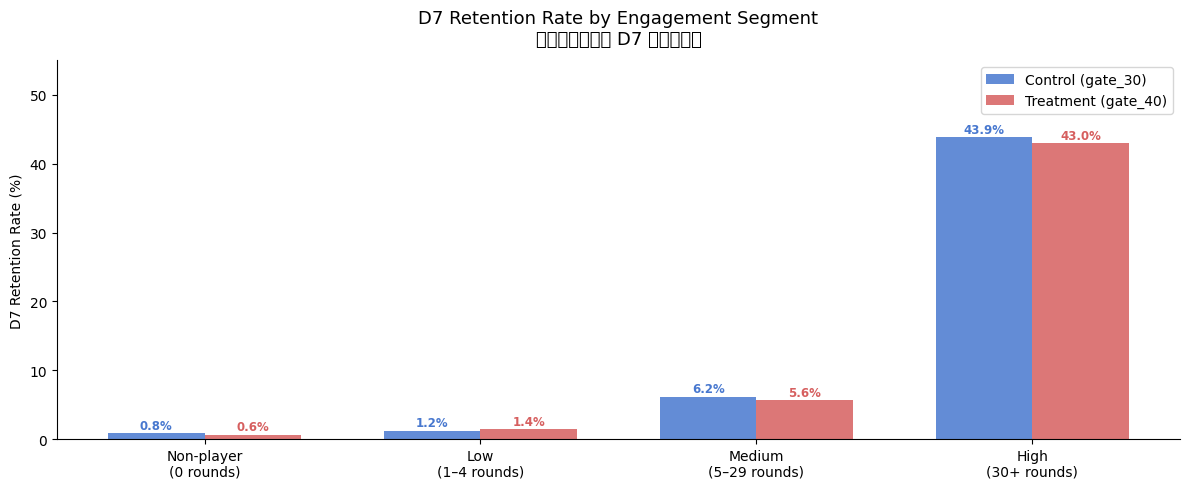

Figure saved ✓


In [4]:
# Chart 1: D7 Retention rates by segment — grouped bar chart
# 图1：各分群 D7 留存率对比柱状图
# Shows control vs treatment side by side for each segment
# 每个分群内并排显示 control 和 treatment 的留存率

seg_labels = ['Non-player\n(0 rounds)', 'Low\n(1–4 rounds)', 'Medium\n(5–29 rounds)', 'High\n(30+ rounds)']
ctrl_rates  = [row['rate_ctrl'] * 100 for _, row in df_results.iterrows()]
trt_rates   = [row['rate_trt']  * 100 for _, row in df_results.iterrows()]

x     = np.arange(len(seg_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, ctrl_rates, width, label='Control (gate_30)', color='#4878CF', alpha=0.85)
bars2 = ax.bar(x + width/2, trt_rates,  width, label='Treatment (gate_40)', color='#D65F5F', alpha=0.85)

# Value labels on each bar / 在每个柱子上标注数值
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8.5,
            color='#4878CF', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8.5,
            color='#D65F5F', fontweight='bold')

ax.set_title('D7 Retention Rate by Engagement Segment\n各参与度分群的 D7 留存率对比', fontsize=13, pad=12)
ax.set_ylabel('D7 Retention Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(seg_labels, fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 55)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/04_retention_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

**Chart 1 takeaway:** Retention rates increase with engagement level across all segments. The treatment group (red) is consistently at or below the control group (blue) in every segment except Low, where the difference is negligible.

**图1 结论：** 留存率随参与度提升而增高。除了 Low 分群略有正向外，treatment 组（红色）在每个分群中都等于或低于 control 组（蓝色）。

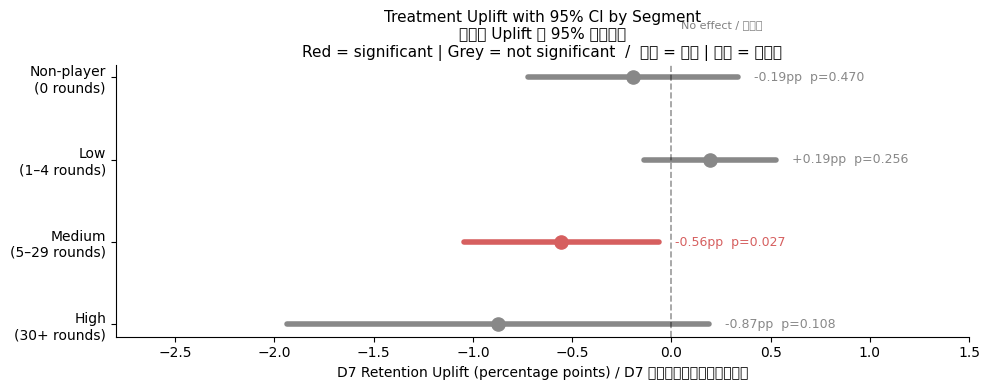

Figure saved ✓


In [5]:
# Chart 2: Uplift + 95% CI per segment
# 图2：各分群的 uplift + 95% 置信区间
# Red = significant (CI entirely below 0)
# 红色 = 显著（CI 完全在 0 以下）
# Grey = not significant (CI crosses 0)
# 灰色 = 不显著（CI 跨过 0）

fig, ax = plt.subplots(figsize=(10, 4))

y_positions  = [3, 2, 1, 0]   # one row per segment / 每个分群一行
seg_labels_ci = ['Non-player\n(0 rounds)', 'Low\n(1–4 rounds)',
                  'Medium\n(5–29 rounds)', 'High\n(30+ rounds)']

for i, (y, (_, r)) in enumerate(zip(y_positions, df_stats.iterrows())):
    uplift = r['uplift'] * 100
    lo     = r['ci_lo']  * 100 if not np.isnan(r['ci_lo']) else uplift
    hi     = r['ci_hi']  * 100 if not np.isnan(r['ci_hi']) else uplift

    # Red if CI entirely below 0 = confirmed negative effect
    # 红色 = CI 完全在 0 以下，效果确认为负
    color = '#D65F5F' if (not np.isnan(r['p_value']) and r['p_value'] < 0.05 and uplift < 0) else '#888888'

    ax.plot([lo, hi], [y, y], color=color, linewidth=4, solid_capstyle='round')
    ax.scatter([uplift], [y], color=color, s=90, zorder=5)
    ax.text(hi + 0.08, y,
            f"{uplift:+.2f}pp  p={r['p_value']:.3f}" if not np.isnan(r['p_value']) else 'n/a',
            va='center', fontsize=9, color=color)

# Zero reference line / 0 基准线
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.4)
ax.text(0.05, 3.6, 'No effect / 无效果', fontsize=8, color='gray')

ax.set_yticks(y_positions)
ax.set_yticklabels(seg_labels_ci, fontsize=10)
ax.set_xlabel('D7 Retention Uplift (percentage points) / D7 留存率提升幅度（百分点）')
ax.set_title('Treatment Uplift with 95% CI by Segment\n各分群 Uplift 与 95% 置信区间\n'
             'Red = significant | Grey = not significant  /  红色 = 显著 | 灰色 = 不显著', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(-2.8, 1.5)

plt.tight_layout()
plt.savefig('../outputs/figures/04_uplift_ci_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

**Chart 2 takeaway:** Only the Medium segment (red line) has a confidence interval entirely to the left of zero — confirming a statistically significant negative effect (p=0.027). All other segments are grey, meaning their differences could be due to random chance.

**图2 结论：** 只有 Medium 分群（红色线段）的置信区间完全在 0 左侧，统计显著（p=0.027）。其余分群均为灰色，说明其差距在随机误差范围内，无法确认真实效果。